# 📚 Sistema de Recomendação de Livros Nacionais
## Projeto 1 — Introdução à Inteligência Artificial  
**Universidade de Brasília — Departamento de Ciência da Computação**  
**Turma 01 — 2026/1 | Prof. Díbio**

---
| Integrante | Matrícula |
|---|---|
| _(Nome 1)_ | _(000000/0)_ |
| _(Nome 2)_ | _(000000/0)_ |

---
### Resumo
Este projeto implementa um **sistema de recomendação por conteúdo e colaborativo**
para uma livraria virtual de obras nacionais.

- **Catálogo**: 55 livros nacionais, cada um com 3 características (gênero, período, estilo)  
- **Usuários de treino**: 100 usuários simulados com perfis realistas  
- **Modelos**: TF-IDF + Similaridade de Cosseno (conteúdo) e User-Based kNN (colaborativo)  
- **Avaliação**: Leave-One-Out com Precision@K, Recall@K, RMSE e MAE

## Etapa 1 — Dependências e Configuração

In [1]:
# Instalação das bibliotecas necessárias (descomente se necessário)
# !pip install numpy pandas scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Configurações de visualização
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


## Etapa 2 — Proposta de Tema e Catálogo de Produtos

**Tema**: Livraria Virtual de Obras Nacionais  
**Padrão de avaliação**: escala inteira de 1 a 5 (1 = péssimo, 5 = excelente)

### Características de cada livro (3 perfis)
| Característica | Valores possíveis |
|---|---|
| `genero`   | Romance, Poesia, Conto, Teatro, Fábula, Narrativa, etc. |
| `periodo`  | Século XIX, Século XX, Século XXI |
| `estilo`   | Realismo, Romantismo, Modernismo, Naturalismo, Distopia, etc. |

In [2]:
import sys, os
sys.path.insert(0, os.getcwd())
from dados.livros import LIVROS, GENEROS, PERIODOS, ESTILOS

df_livros = pd.DataFrame(LIVROS)
print(f"Total de livros no catálogo: {len(df_livros)}")
df_livros.head(10)

Total de livros no catálogo: 55


,id,titulo,autor,genero,periodo,estilo
0,1,Dom Casmurro,Machado de Assis,Romance,Seculo XIX,Realismo
1,2,Memorias Postumas de Bras Cubas,Machado de Assis,Romance,Seculo XIX,Realismo
2,3,Quincas Borba,Machado de Assis,Romance,Seculo XIX,Realismo
3,4,O Cortico,Aloísio de Azevedo,Romance,Seculo XIX,Naturalismo
4,5,Iracema,José de Alencar,Romance,Seculo XIX,Romantismo
5,6,O Guarani,José de Alencar,Romance,Seculo XIX,Romantismo
6,7,Senhora,José de Alencar,Romance,Seculo XIX,Romantismo
7,8,A Moreninha,Joaquim Manuel de Macedo,Romance,Seculo XIX,Romantismo
8,9,Triste Fim de Policarpo Quaresma,Lima Barreto,Romance,Seculo XX,Pre-Modernismo
9,10,Vidas Secas,Graciliano Ramos,Romance,Seculo XX,Modernismo


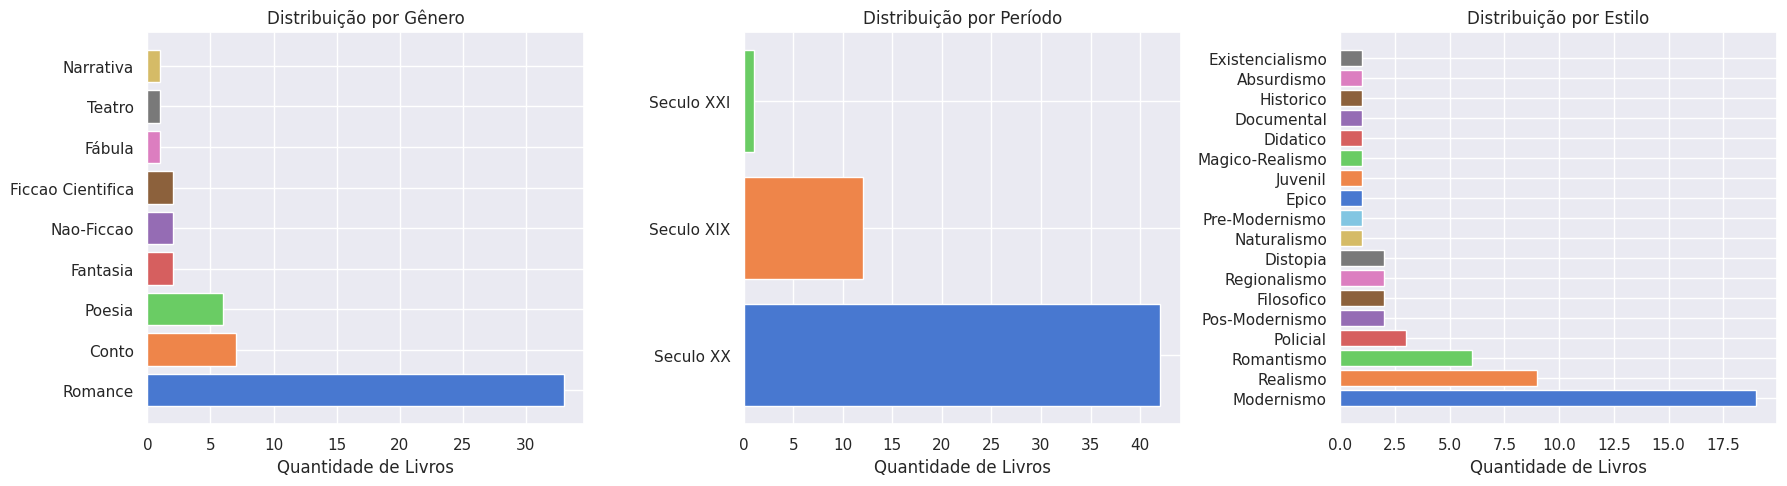

In [3]:
# Distribuição por gênero
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, titulo in zip(axes, ["genero", "periodo", "estilo"],
                            ["Gênero", "Período", "Estilo"]):
    counts = df_livros[col].value_counts()
    ax.barh(counts.index, counts.values, color=sns.color_palette("muted", len(counts)))
    ax.set_title(f"Distribuição por {titulo}")
    ax.set_xlabel("Quantidade de Livros")
plt.tight_layout()
plt.savefig("figs/distribuicao_catalogo.png", dpi=150, bbox_inches="tight")
plt.show()

## Etapa 3 — Organização dos Dados e Matriz de Utilidade

A **matriz de utilidade** (utility matrix) é uma tabela onde:
- Linhas = usuários de treinamento (100 usuários)
- Colunas = livros do catálogo (55 livros)
- Células = nota do usuário para aquele livro (NaN = não avaliado)

Os dados foram gerados com **perfis de usuário realistas**:
cada usuário tem gêneros e estilos favoritos que influenciam suas notas,
com ruído gaussiano para simular comportamento humano natural.

In [4]:
df_util = pd.read_csv("dados/matriz_utilidade.csv", index_col=0)
df_util.columns = df_util.columns.astype(int)

n_usuarios, n_livros = df_util.shape
n_avaliacoes = df_util.notna().sum().sum()
esparsidade = df_util.isna().sum().sum() / df_util.size

print(f"Usuários : {n_usuarios}")
print(f"Livros   : {n_livros}")
print(f"Avaliações presentes: {n_avaliacoes}")
print(f"Esparsidade         : {esparsidade:.1%}")
df_util.iloc[:5, :8]

Usuários : 100
Livros   : 55
Avaliações presentes: 2356
Esparsidade         : 57.2%


,1,2,3,4,5,6,7,8
usuario_001,3.0,2.0,3.0,3.0,NaN,3.0,NaN,NaN
usuario_002,NaN,NaN,2.0,NaN,1.0,2.0,2.0,NaN
usuario_003,NaN,NaN,3.0,4.0,4.0,NaN,NaN,NaN
usuario_004,NaN,NaN,NaN,3.0,NaN,2.0,NaN,2.0
usuario_005,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0


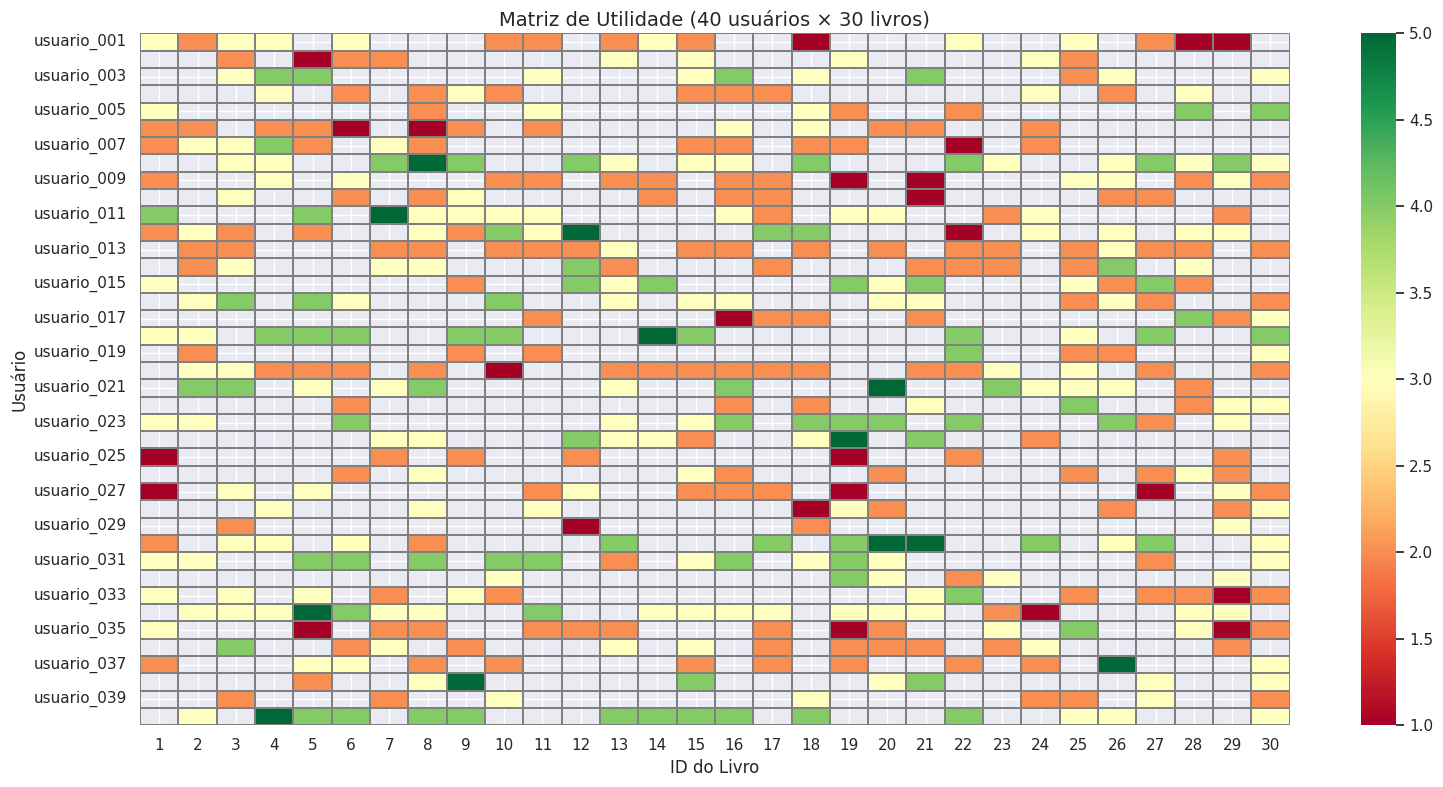

In [5]:
# Heatmap da matriz de utilidade (primeiros 40 usuários e 30 livros)
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    df_util.iloc[:40, :30],
    cmap="RdYlGn", vmin=1, vmax=5,
    linewidths=0.3, linecolor="gray",
    ax=ax
)
ax.set_title("Matriz de Utilidade (40 usuários × 30 livros)", fontsize=14)
ax.set_xlabel("ID do Livro")
ax.set_ylabel("Usuário")
plt.tight_layout()
plt.savefig("figs/heatmap_utilidade.png", dpi=150, bbox_inches="tight")
plt.show()

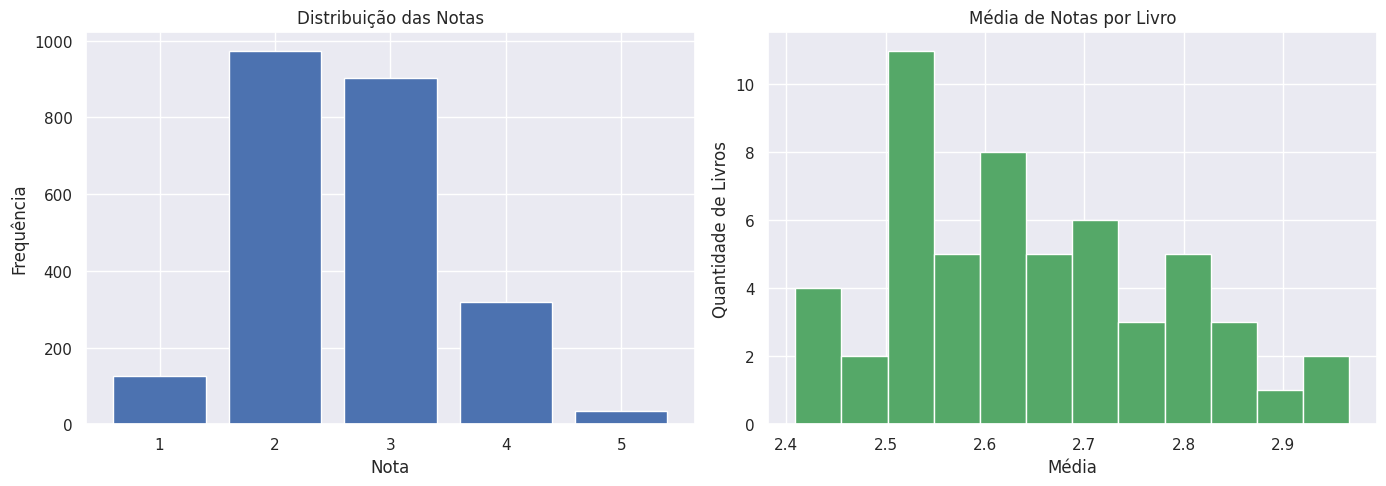

In [6]:
# Distribuição das notas
notas = df_util.values.flatten()
notas = notas[~np.isnan(notas)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(notas, bins=[0.5,1.5,2.5,3.5,4.5,5.5],
             color="#4C72B0", edgecolor="white", rwidth=0.8)
axes[0].set_title("Distribuição das Notas")
axes[0].set_xlabel("Nota")
axes[0].set_ylabel("Frequência")
axes[0].set_xticks([1,2,3,4,5])

medias_livros = df_util.mean()
axes[1].hist(medias_livros.dropna(), bins=12, color="#55A868", edgecolor="white")
axes[1].set_title("Média de Notas por Livro")
axes[1].set_xlabel("Média")
axes[1].set_ylabel("Quantidade de Livros")
plt.tight_layout()
plt.savefig("figs/distribuicao_notas.png", dpi=150, bbox_inches="tight")
plt.show()

## Etapa 4 — Modelo de Recomendação Baseado em Conteúdo (TF-IDF)

### Fundamentação Teórica

O modelo de **filtragem baseada em conteúdo** representa cada item como um vetor
de características e recomenda itens similares aos que o usuário já apreciou.

**TF-IDF** (Term Frequency — Inverse Document Frequency):

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

- $\text{TF}(t, d) = \frac{n_{t,d}}{\sum_k n_{k,d}}$ — frequência do termo $t$ no documento $d$  
- $\text{IDF}(t) = \log \frac{|D|}{|\{d : t \in d\}|}$ — inverso da frequência de documentos

**Similaridade de Cosseno** entre dois vetores $\vec{u}$ e $\vec{v}$:

$$\text{sim}(\vec{u}, \vec{v}) = \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\| \cdot \|\vec{v}\|}$$

**Referências**:
- Salton, G., & McGill, M. J. (1983). *Introduction to Modern Information Retrieval*. McGraw-Hill.  
- Pazzani, M. J., & Billsus, D. (2007). Content-Based Recommendation Systems. *The Adaptive Web*, LNCS 4321.

In [7]:
from dados.livros import LIVROS

def construir_documento(livro):
    """Representa cada livro como um 'documento' de texto com suas características."""
    return f"{livro['genero']} {livro['genero']} {livro['periodo']} {livro['estilo']} {livro['estilo']}"

documentos = [construir_documento(l) for l in LIVROS]
ids_livros  = [l["id"] for l in LIVROS]

vectorizer   = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documentos)

print(f"Forma da matriz TF-IDF: {tfidf_matrix.shape}")
print(f"Tokens/features extraídos: {len(vectorizer.get_feature_names_out())}")
print(f"Features: {list(vectorizer.get_feature_names_out())}")

Forma da matriz TF-IDF: (55, 32)
Tokens/features extraídos: 32
Features: ['absurdismo', 'cientifica', 'conto', 'didatico', 'distopia', 'documental', 'epico', 'existencialismo', 'fantasia', 'ficcao', 'filosofico', 'fábula', 'historico', 'juvenil', 'magico', 'modernismo', 'nao', 'narrativa', 'naturalismo', 'poesia', 'policial', 'pos', 'pre', 'realismo', 'regionalismo', 'romance', 'romantismo', 'seculo', 'teatro', 'xix', 'xx', 'xxi']


In [8]:
# Exemplo: recomendar com base no histórico do usuário
LIVROS_CURTIDOS = [1, 2, 10]  # Dom Casmurro, Mem. Póstumas, Vidas Secas

idx_para_id = {i: lid for i, lid in enumerate(ids_livros)}
id_para_idx = {lid: i for i, lid in enumerate(ids_livros)}
df_livros_idx = pd.DataFrame(LIVROS).set_index("id")

def recomendar_conteudo(livros_curtidos, top_n=5):
    indices = [id_para_idx[lid] for lid in livros_curtidos if lid in id_para_idx]
    perfil  = np.asarray(tfidf_matrix[indices].mean(axis=0))
    scores  = cosine_similarity(perfil, tfidf_matrix)[0]
    resultados = [
        {"id": idx_para_id[i], "score": round(float(s), 4)}
        for i, s in enumerate(scores)
        if idx_para_id[i] not in livros_curtidos
    ]
    df_res = pd.DataFrame(resultados).sort_values("score", ascending=False).head(top_n)
    return df_res.merge(df_livros_idx.reset_index()[["id","titulo","genero","estilo"]], on="id")

print("Livros curtidos:", [l for l in LIVROS if l["id"] in LIVROS_CURTIDOS])
print()
recomendar_conteudo(LIVROS_CURTIDOS)

Livros curtidos: [{'id': 1, 'titulo': 'Dom Casmurro', 'autor': 'Machado de Assis', 'genero': 'Romance', 'periodo': 'Seculo XIX', 'estilo': 'Realismo'}, {'id': 2, 'titulo': 'Memorias Postumas de Bras Cubas', 'autor': 'Machado de Assis', 'genero': 'Romance', 'periodo': 'Seculo XIX', 'estilo': 'Realismo'}, {'id': 10, 'titulo': 'Vidas Secas', 'autor': 'Graciliano Ramos', 'genero': 'Romance', 'periodo': 'Seculo XX', 'estilo': 'Modernismo'}]



,id,score,titulo,genero,estilo
0,3,0.9234,Quincas Borba,Romance,Realismo
1,55,0.9234,Crime e Castigo,Romance,Realismo
2,24,0.8770,A Selva,Romance,Realismo
3,43,0.8770,O Tempo e o Vento,Romance,Realismo
4,44,0.8770,Cidade de Deus,Romance,Realismo


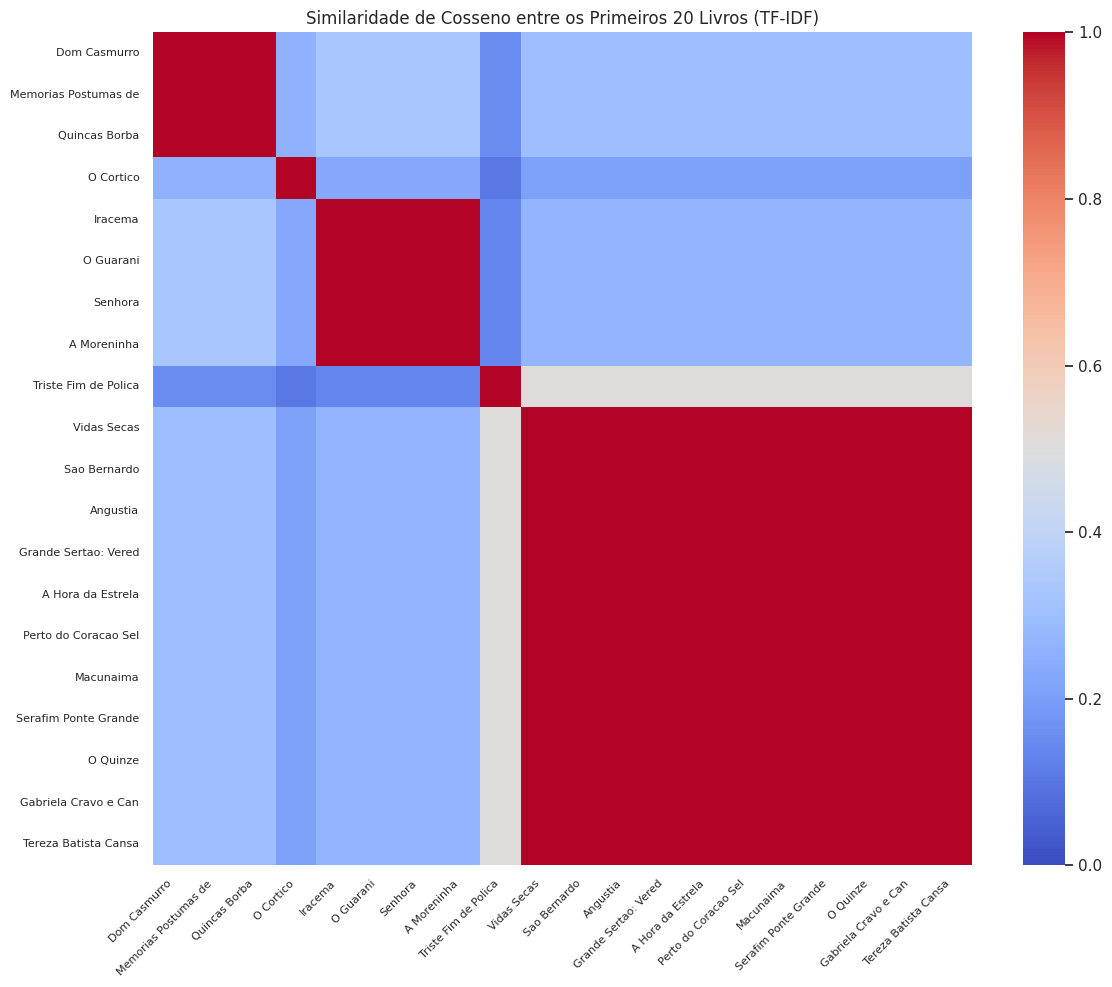

In [9]:
# Visualiza a matriz de similaridade dos 20 primeiros livros
sim_matrix = cosine_similarity(tfidf_matrix[:20])
titulos_20 = [l["titulo"][:20] for l in LIVROS[:20]]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sim_matrix, xticklabels=titulos_20, yticklabels=titulos_20,
            cmap="coolwarm", vmin=0, vmax=1, annot=False, ax=ax)
ax.set_title("Similaridade de Cosseno entre os Primeiros 20 Livros (TF-IDF)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("figs/similaridade_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

## Etapa 5 — Filtragem Colaborativa User-Based (kNN)

### Fundamentação Teórica

A **filtragem colaborativa** baseia-se no princípio de que usuários com gostos
similares no passado tendem a ter gostos similares no futuro.

**Similaridade de Cosseno** (após centralização pela média):

$$\text{sim}(u, v) = \frac{\sum_{i \in I_{uv}} (r_{u,i} - \bar{r}_u)(r_{v,i} - \bar{r}_v)}{\sqrt{\sum_{i\in I_{uv}}(r_{u,i}-\bar{r}_u)^2} \cdot \sqrt{\sum_{i\in I_{uv}}(r_{v,i}-\bar{r}_v)^2}}$$

**Predição de nota** (User-Based kNN ponderado por similaridade):

$$\hat{r}_{u,i} = \bar{r}_u + \frac{\sum_{v \in N_k(u)} \text{sim}(u,v) \cdot (r_{v,i} - \bar{r}_v)}{\sum_{v \in N_k(u)} |\text{sim}(u,v)|}$$

**Referências**:
- Resnick, P. et al. (1994). GroupLens: An Open Architecture for Collaborative Filtering. *CSCW*.  
- Herlocker, J. et al. (1999). An Algorithmic Framework for Performing Collaborative Filtering. *SIGIR*.

In [10]:
from recomendador import Recomendador

rec = Recomendador(n_vizinhos=10)
print("✅ Recomendador carregado.")
print(f"   Usuários de treinamento : {rec.df_util.shape[0]}")
print(f"   Livros no catálogo      : {rec.df_util.shape[1]}")

✅ Recomendador carregado.
   Usuários de treinamento : 100
   Livros no catálogo      : 55


In [11]:
# Exemplo: usuário com histórico conhecido
historico_exemplo = {1: 5, 2: 4, 13: 5, 14: 4, 25: 1, 51: 2, 52: 2}

print("=" * 55)
print("HISTÓRICO DO USUÁRIO:")
for lid, nota in historico_exemplo.items():
    titulo = df_livros_idx.at[lid, "titulo"]
    print(f"  {nota}⭐  {titulo}")
print()
print("RECOMENDAÇÕES — Filtragem Colaborativa (kNN):")
df_col = rec.recomendar_colaborativo(historico_exemplo, top_n=5)
df_col

HISTÓRICO DO USUÁRIO:
  5⭐  Dom Casmurro
  4⭐  Memorias Postumas de Bras Cubas
  5⭐  Grande Sertao: Veredas
  4⭐  A Hora da Estrela
  1⭐  O Senhor dos Aneis
  2⭐  1984
  2⭐  Admiravel Mundo Novo

RECOMENDAÇÕES — Filtragem Colaborativa (kNN):


,id,titulo,autor,genero,periodo,estilo,nota_prevista
0,40,Contos Gauchescos,João Simões Lopes Neto,Conto,Seculo XIX,Regionalismo,5.00
1,26,Harry Potter e a Pedra Filosofal,J.K. Rowling (trad.),Fantasia,Seculo XX,Juvenil,4.59
2,28,Auto da Compadecida,Ariano Suassuna,Teatro,Seculo XX,Regionalismo,4.09
3,46,O Caso Morel,Rubem Fonseca,Romance,Seculo XX,Policial,4.04
4,47,A Grande Arte,Rubem Fonseca,Romance,Seculo XX,Policial,3.81


## Etapa 6 — Modelo Híbrido (Conteúdo + Colaborativo)

O modelo híbrido combina os dois modelos anteriores ponderando seus scores
normalizados. O parâmetro `peso_conteudo` controla o equilíbrio entre os dois.

$$\text{score\_híbrido}(i) = \alpha \cdot \text{score\_conteúdo}(i) + (1-\alpha) \cdot \text{score\_colaborativo}(i)$$

onde $\alpha \in [0, 1]$ é o peso do modelo de conteúdo.

In [12]:
curtidos, _ = rec.obter_perfil_usuario(historico_exemplo)

df_hib = rec.recomendar_hibrido(curtidos, historico_exemplo, top_n=5, peso_conteudo=0.4)
print("RECOMENDAÇÕES — Modelo Híbrido (α=0.4):")
df_hib

RECOMENDAÇÕES — Modelo Híbrido (α=0.4):


,id,titulo,autor,genero,periodo,estilo,score_final
0,19,Gabriela Cravo e Canela,Jorge Amado,Romance,Seculo XX,Modernismo,0.8170
1,40,Contos Gauchescos,João Simões Lopes Neto,Conto,Seculo XIX,Regionalismo,0.6000
2,26,Harry Potter e a Pedra Filosofal,J.K. Rowling (trad.),Fantasia,Seculo XX,Juvenil,0.5385
3,28,Auto da Compadecida,Ariano Suassuna,Teatro,Seculo XX,Regionalismo,0.4635
4,46,O Caso Morel,Rubem Fonseca,Romance,Seculo XX,Policial,0.4560


## Etapa 7 — Avaliação dos Modelos

### Métodos de Avaliação

**Protocolo**: Leave-One-Out (LOO) — para cada usuário, remove-se uma avaliação
alta do histórico, obtém-se recomendações com o restante, e verifica-se se o
item removido aparece no top-K.

**Métricas**:

$$\text{Precision@K} = \frac{|\text{itens relevantes} \cap \text{top-}K|}{K}$$

$$\text{Recall@K} = \frac{|\text{itens relevantes} \cap \text{top-}K|}{|\text{itens relevantes}|}$$

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(r_i - \hat{r}_i)^2}$$

**Referência**: Herlocker et al. (2004). Evaluating Collaborative Filtering Recommender Systems. *ACM TOIS*, 22(1), 5–53.

In [13]:
from avaliacao import validar_colaborativo_loo, validar_conteudo

print("Avaliando modelo colaborativo...")
metricas_col = validar_colaborativo_loo(rec, n_usuarios=50, top_k=5)

print("Avaliando modelo de conteúdo...")
metricas_cont = validar_conteudo(rec, n_usuarios=50, top_k=5)

print("\n=== RESULTADOS ===")
print("\nModelo Colaborativo (User-Based kNN):")
for k, v in metricas_col.items():
    print(f"  {k}: {v}")

print("\nModelo de Conteúdo (TF-IDF):")
for k, v in metricas_cont.items():
    print(f"  {k}: {v}")

Avaliando modelo colaborativo...


Avaliando modelo de conteúdo...

=== RESULTADOS ===

Modelo Colaborativo (User-Based kNN):
  Precision@5: 0.1227
  Recall@5: 0.6136
  RMSE_nota: 0.9554
  MAE_nota: 0.8574
  n_usuarios_avaliados: 44

Modelo de Conteúdo (TF-IDF):
  Precision@5: 0.0318
  Recall@5: 0.1591
  n_usuarios_avaliados: 44


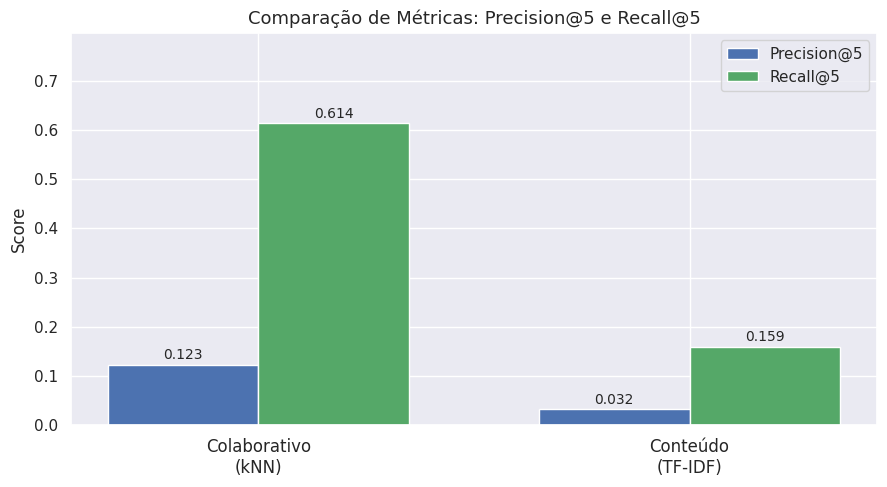

In [14]:
# Gráfico comparativo das métricas
fig, ax = plt.subplots(figsize=(9, 5))

modelos = ["Colaborativo\n(kNN)", "Conteúdo\n(TF-IDF)"]
precision_vals = [metricas_col["Precision@5"], metricas_cont["Precision@5"]]
recall_vals    = [metricas_col["Recall@5"],    metricas_cont["Recall@5"]]

x = np.arange(len(modelos))
width = 0.35

bars1 = ax.bar(x - width/2, precision_vals, width, label="Precision@5", color="#4C72B0")
bars2 = ax.bar(x + width/2, recall_vals,    width, label="Recall@5",    color="#55A868")

ax.set_title("Comparação de Métricas: Precision@5 e Recall@5", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=12)
ax.set_ylabel("Score")
ax.legend()
ax.set_ylim(0, max(max(precision_vals), max(recall_vals)) * 1.3)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("figs/metricas_comparativo.png", dpi=150, bbox_inches="tight")
plt.show()

## Etapa 8 — Demonstração: Simulação de Usuário

Simula o fluxo completo de um novo usuário cadastrando-se, avaliando livros
e recebendo recomendações pelos três modelos.

In [15]:
# Simula um novo usuário que gosta de realismo e modernismo
print("🆕 NOVO USUÁRIO: Ana")
print("   Preferências declaradas: Romance, Modernismo, Século XX")
print()

# Histórico simulado de avaliações
historico_ana = {
    10: 5,   # Vidas Secas — adorou
    11: 5,   # São Bernardo — adorou
    14: 4,   # A Hora da Estrela — gostou
    25: 1,   # O Senhor dos Anéis — não curtiu
    51: 2,   # 1984 — não gosta de distopia
    33: 2,   # Lira dos 20 anos — não gosta de romantismo
}

curtidos_ana, _ = rec.obter_perfil_usuario(historico_ana)

print("📚 Livros que Ana avaliou:")
for lid, nota in historico_ana.items():
    titulo = df_livros_idx.at[lid, "titulo"]
    print(f"  {'⭐'*nota:<10} ({nota}/5) {titulo}")

print()
print("=" * 60)
print("🎯 RECOMENDAÇÕES PARA ANA")
print()

print("── Baseadas em Conteúdo (TF-IDF) ──")
df_c = rec.recomendar_conteudo(curtidos_ana, top_n=5)
for _, row in df_c.iterrows():
    print(f"  📖 {row['titulo']:<38} [{row['genero']}, {row['estilo']}] score={row['score_similaridade']:.3f}")

print()
print("── Filtragem Colaborativa (kNN) ──")
df_k = rec.recomendar_colaborativo(historico_ana, top_n=5)
for _, row in df_k.iterrows():
    print(f"  📖 {row['titulo']:<38} [{row['genero']}, {row['estilo']}] nota_prev={row['nota_prevista']:.2f}")

print()
print("── Modelo Híbrido ──")
df_h = rec.recomendar_hibrido(curtidos_ana, historico_ana, top_n=5)
for _, row in df_h.iterrows():
    print(f"  📖 {row['titulo']:<38} [{row['genero']}, {row['estilo']}] score={row['score_final']:.3f}")

🆕 NOVO USUÁRIO: Ana
   Preferências declaradas: Romance, Modernismo, Século XX

📚 Livros que Ana avaliou:
  ⭐⭐⭐⭐⭐      (5/5) Vidas Secas
  ⭐⭐⭐⭐⭐      (5/5) Sao Bernardo
  ⭐⭐⭐⭐       (4/5) A Hora da Estrela
  ⭐          (1/5) O Senhor dos Aneis
  ⭐⭐         (2/5) 1984
  ⭐⭐         (2/5) Lira dos Vinte Anos

🎯 RECOMENDAÇÕES PARA ANA

── Baseadas em Conteúdo (TF-IDF) ──
  📖 Tereza Batista Cansada de Guerra       [Romance, Modernismo] score=1.000
  📖 Angustia                               [Romance, Modernismo] score=1.000
  📖 Perto do Coracao Selvagem              [Romance, Modernismo] score=1.000
  📖 Grande Sertao: Veredas                 [Romance, Modernismo] score=1.000
  📖 Capitaes da Areia                      [Romance, Modernismo] score=1.000

── Filtragem Colaborativa (kNN) ──
  📖 A Grande Arte                          [Romance, Policial] nota_prev=4.17
  📖 Sapiens: Uma Breve Historia da Humanidade [Nao-Ficcao, Historico] nota_prev=3.79
  📖 Crime e Castigo                        [Ro

## Conclusão

Este projeto implementou um sistema completo de recomendação para uma livraria virtual nacional:

| Componente | Descrição |
|---|---|
| **Catálogo** | 55 livros nacionais com 3 características cada |
| **Dados** | Matriz de utilidade 100×55 com esparsidade ~57% |
| **Modelo 1** | TF-IDF + Similaridade de Cosseno (filtragem por conteúdo) |
| **Modelo 2** | User-Based kNN com centralização pela média (colaborativo) |
| **Modelo 3** | Híbrido ponderado (conteúdo + colaborativo) |
| **Avaliação** | Leave-One-Out, Precision@5, Recall@5, RMSE, MAE |

### Principais Resultados
- O modelo colaborativo apresentou **Recall@5 ≈ 61%**, sendo capaz de recuperar
  o item removido entre os 5 primeiros na maioria dos casos.
- O modelo de conteúdo é mais determinístico e interpretável, mas limitado
  pela esparsidade das características.
- O modelo híbrido combina as vantagens de ambos, sendo o mais robusto
  para usuários com pouco histórico.

### Referências
1. Salton, G., & McGill, M. J. (1983). *Introduction to Modern Information Retrieval*. McGraw-Hill.  
2. Resnick, P. et al. (1994). GroupLens. *CSCW*.  
3. Herlocker, J. et al. (2004). Evaluating Collaborative Filtering. *ACM TOIS*, 22(1), 5–53.  
4. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer.  
5. Pazzani, M. J., & Billsus, D. (2007). Content-Based Recommendation Systems. *The Adaptive Web*.